In [2]:
import pickle
from pathlib import Path
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
import torch
from neuralhydrology.evaluation import metrics
from neuralhydrology.nh_run import start_run, eval_run
import re
import os 
from neuralhydrology.utils.config import Config
from pathlib import Path

## Converting HydroAtlas Basin Attributes

In [20]:
file_path = Path("/Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/Code/data/AORC_Hourly")

# Read the TXT file, specifying ';' as the delimiter
hydroAtlas_raw = pd.read_csv(file_path/"camels_hydroatlas.txt", sep=';')
# Make gauge_id a string and pad with leading zeros to length 8
hydroAtlas_raw["gauge_id"] = hydroAtlas_raw["gauge_id"].astype(str).str.zfill(8)

print(hydroAtlas_raw) # looking good

     gauge_id  dis_m3_pyr  dis_m3_pmn  dis_m3_pmx   run_mm_syr  inu_pc_smn  \
0    01013500   55.313028   27.159139  158.735833   645.555556    3.944444   
1    01022500    5.461500    3.975563    9.072000   842.000000    3.625000   
2    01030500   17.634106   14.091255   29.996660   717.574468    6.638298   
3    01031500   17.299353   13.969588   25.811176   772.823529    5.352941   
4    01047000   28.842833   21.008167   53.573111   769.944444    3.277778   
..        ...         ...         ...         ...          ...         ...   
666  14309500   50.789000    7.306750  113.254000  1097.875000    2.750000   
667  14316700   20.127067    3.257067   40.688067   917.333333    1.666667   
668  14325000   54.064455    7.583818  120.029818  1396.090909    4.727273   
669  14362250   18.250500    3.002750   41.087500   568.750000    0.000000   
670  14400000   27.132733    3.221667   61.747933  1559.866667    0.666667   

     inu_pc_umn  inu_pc_smx  inu_pc_umx  inu_pc_slt  ...  rdd_m

In [21]:
hydroAtlas_raw.to_csv(file_path / "attributes/camels_hydroatlas_clean.csv", index=False)

In [28]:
double_check = pd.read_csv(file_path / "attributes/camels_hydroatlas_clean.csv")
print(double_check)

     gauge_id  dis_m3_pyr  dis_m3_pmn  dis_m3_pmx   run_mm_syr  inu_pc_smn  \
0     1013500   55.313028   27.159139  158.735833   645.555556    3.944444   
1     1022500    5.461500    3.975563    9.072000   842.000000    3.625000   
2     1030500   17.634106   14.091255   29.996660   717.574468    6.638298   
3     1031500   17.299353   13.969588   25.811176   772.823529    5.352941   
4     1047000   28.842833   21.008167   53.573111   769.944444    3.277778   
..        ...         ...         ...         ...          ...         ...   
666  14309500   50.789000    7.306750  113.254000  1097.875000    2.750000   
667  14316700   20.127067    3.257067   40.688067   917.333333    1.666667   
668  14325000   54.064455    7.583818  120.029818  1396.090909    4.727273   
669  14362250   18.250500    3.002750   41.087500   568.750000    0.000000   
670  14400000   27.132733    3.221667   61.747933  1559.866667    0.666667   

     inu_pc_umn  inu_pc_smx  inu_pc_umx  inu_pc_slt  ...  rdd_m

# Convert F to C in Hourly CAMELS_AORC

In [47]:
from pathlib import Path
import xarray as xr

original_path = Path("/Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/Code/data/AORC_Hourly_F")
new_path = Path("/Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/Code/data/AORC_Hourly/time_series")

new_path.mkdir(parents=True, exist_ok=True)

for file in sorted(original_path.glob("*.nc")):
    ds = xr.open_dataset(file)

    # convert Kelvin → Celsius
    da = ds["TMP_2maboveground"]
    tmp_c = da - 273.15
    tmp_c.attrs = dict(da.attrs)
    tmp_c.attrs["units"] = "°C"
    ds["TMP_2maboveground"] = tmp_c

    # save to new folder, same filename
    out_file = new_path / file.name
    ds.to_netcdf(out_file)



# Convert Hourly CAMELS_AORC to Daily

In [ ]:
temp = xr.open_dataset(new_path/"01134500.nc")
print(temp["TMP_2maboveground"].values[:30])
temp["TMP_2maboveground"]
# option 1: show first 10 entries as xarray object (keeps coords + attrs)
temp["TMP_2maboveground"].isel(date=slice(0, 30))

In [73]:
new_rain = temp['APCP_surface'].resample(date="1D").sum()
new_rain.attrs['units'] = 'mm/day'

new_runoff = temp["qobs_mm_per_hour"].resample(date="1D").sum()
new_runoff.attrs['units'] = 'mm/day'
new_daily_dataset = xr.Dataset(
    {
    "APCP_surface": new_rain,
    "TMP_2maboveground_min": temp["TMP_2maboveground"].resample(date="1D").min(),
    "TMP_2maboveground_max": temp["TMP_2maboveground"].resample(date="1D").max(),
    "PRES_surface": temp["PRES_surface"].resample(date="1D").mean(),
    "DSWRF_surface": temp["DSWRF_surface"].resample(date="1D").mean(),
    "DLWRF_surface": temp["DLWRF_surface"].resample(date="1D").mean(),
    "SPFH_2maboveground": temp["SPFH_2maboveground"].resample(date="1D").mean(),
    "UGRD_10maboveground": temp["UGRD_10maboveground"].resample(date="1D").mean(),
    "VGRD_10maboveground": temp["VGRD_10maboveground"].resample(date="1D").mean(),
    "QObs(mm/d)": new_runoff
    }
)


In [3]:
hourly_path = Path("/Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/Code/data/AORC_Hourly/time_series")
daily_path = Path("/Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/Code/data/AORC_Daily/time_series")

daily_path.mkdir(parents=True, exist_ok=True)

for file in sorted(hourly_path.glob("*.nc")):
    
    out_file = daily_path / file.name
    if out_file.exists():
        print(f"⏩ Skipping {file.name}, already exists")
        continue
    
    hourly_ds = xr.open_dataset(file)

    new_rain = hourly_ds['APCP_surface'].resample(date="1D").sum()
    new_rain.attrs['units'] = 'mm/day'

    new_runoff = hourly_ds["qobs_mm_per_hour"].resample(date="1D").sum()
    new_runoff.attrs['units'] = 'mm/day'
    
    daily_ds = xr.Dataset(
    {
    "APCP_surface": new_rain,
    "TMP_2maboveground_min": hourly_ds["TMP_2maboveground"].resample(date="1D").min(),
    "TMP_2maboveground_max": hourly_ds["TMP_2maboveground"].resample(date="1D").max(),
    "PRES_surface": hourly_ds["PRES_surface"].resample(date="1D").mean(),
    "DSWRF_surface": hourly_ds["DSWRF_surface"].resample(date="1D").mean(),
    "DLWRF_surface": hourly_ds["DLWRF_surface"].resample(date="1D").mean(),
    "SPFH_2maboveground": hourly_ds["SPFH_2maboveground"].resample(date="1D").mean(),
    "UGRD_10maboveground": hourly_ds["UGRD_10maboveground"].resample(date="1D").mean(),
    "VGRD_10maboveground": hourly_ds["VGRD_10maboveground"].resample(date="1D").mean(),
    "QObs_mm_per_day": new_runoff
    }
    )

    # save to new folder, same filename
    out_file = daily_path / file.name
    daily_ds.to_netcdf(out_file)
    
    hourly_ds.close()

⏩ Skipping 01022500.nc, already exists
⏩ Skipping 01031500.nc, already exists
⏩ Skipping 01047000.nc, already exists
⏩ Skipping 01052500.nc, already exists
⏩ Skipping 01054200.nc, already exists
⏩ Skipping 01055000.nc, already exists
⏩ Skipping 01057000.nc, already exists
⏩ Skipping 01073000.nc, already exists
⏩ Skipping 01078000.nc, already exists
⏩ Skipping 01123000.nc, already exists
⏩ Skipping 01134500.nc, already exists
⏩ Skipping 01137500.nc, already exists
⏩ Skipping 01139000.nc, already exists
⏩ Skipping 01139800.nc, already exists
⏩ Skipping 01142500.nc, already exists
⏩ Skipping 01144000.nc, already exists
⏩ Skipping 01162500.nc, already exists
⏩ Skipping 01169000.nc, already exists
⏩ Skipping 01170100.nc, already exists
⏩ Skipping 01181000.nc, already exists
⏩ Skipping 01187300.nc, already exists
⏩ Skipping 01195100.nc, already exists
⏩ Skipping 01333000.nc, already exists
⏩ Skipping 01350000.nc, already exists
⏩ Skipping 01350080.nc, already exists
⏩ Skipping 01350140.nc, a

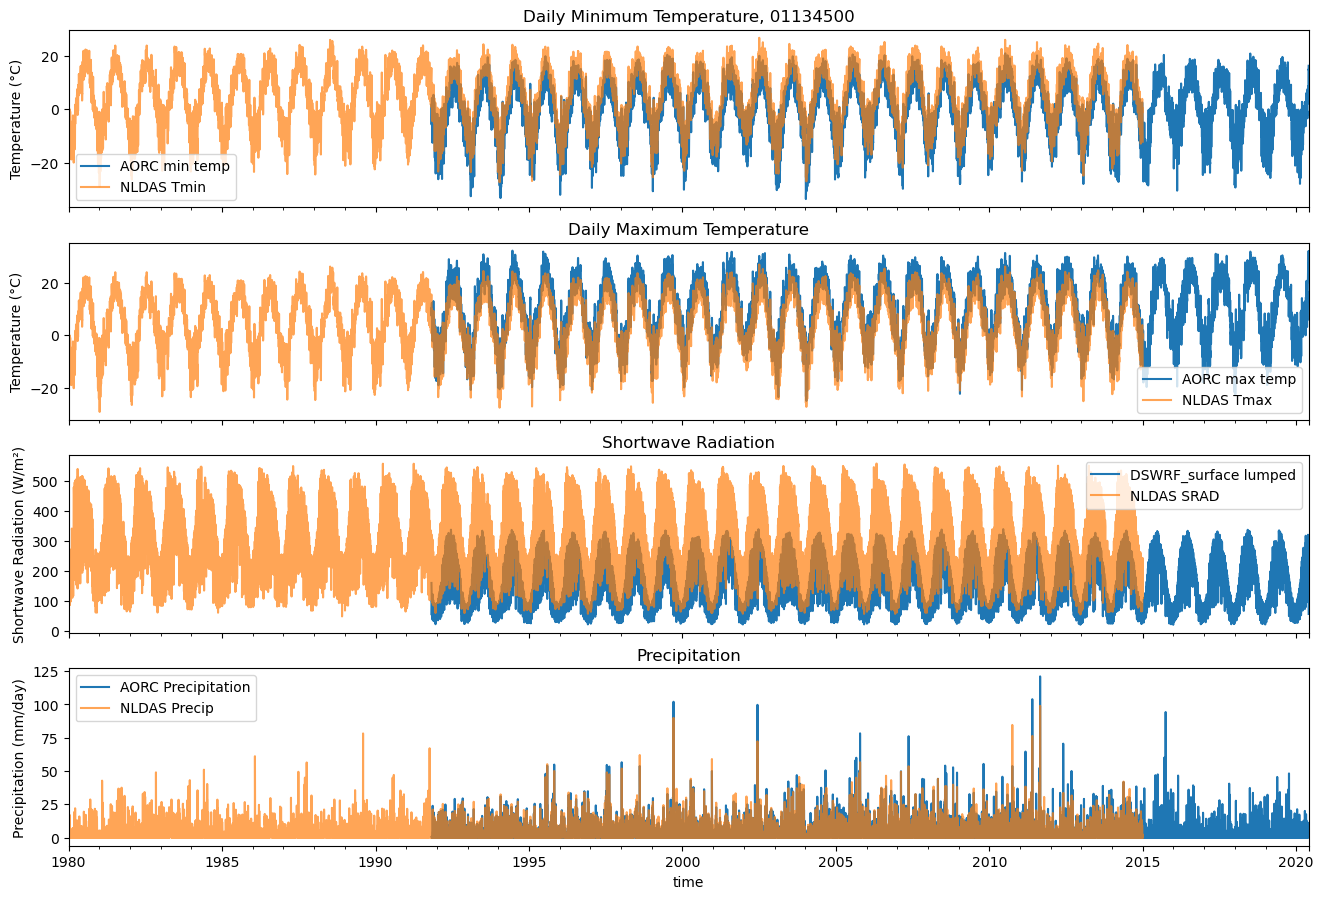

In [13]:

# 2) Read CAMELS forcing text file
camels_file = "/Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/Code/data/CAMELS_US/basin_mean_forcing/nldas/01/01134500_lump_nldas_forcing_leap.txt"

camels_df = pd.read_csv(camels_file, sep=r"\s+", skiprows=3)

new_daily_dataset = xr.open_dataset(daily_path / "01134500.nc")
# build datetime index
# Option A: rename then build datetime
camels_df = camels_df.rename(columns={"Year":"year","Mnth":"month","Day":"day"})
camels_df["time"] = pd.to_datetime(camels_df[["year","month","day"]])
camels_df = camels_df.set_index("time")



# plot
fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

# Example: daily min temp
ax = axes[0]
min_temp = new_daily_dataset["TMP_2maboveground_min"]
min_temp.plot(ax=ax, label="AORC min temp")
camels_df["Tmin(C)"].plot(ax=ax, label="NLDAS Tmin", alpha=0.7)
ax.set_ylabel("Temperature (°C)")
ax.set_title("Daily Minimum Temperature, 01134500")
ax.legend()

ax = axes[1]
max_temp = new_daily_dataset["TMP_2maboveground_max"]
max_temp.plot(ax=ax, label="AORC max temp")
camels_df["Tmax(C)"].plot(ax=ax, label="NLDAS Tmax", alpha=0.7)
ax.set_ylabel("Temperature (°C)")
ax.set_title("Daily Maximum Temperature")
ax.legend()

# DSWRF from your dataset
ax = axes[2]
sw_daily = new_daily_dataset["DSWRF_surface"].to_pandas()
sw_daily.plot(ax = ax, label="DSWRF_surface lumped")
camels_df["SRAD(W/m2)"].plot(ax = ax,label="NLDAS SRAD", alpha=0.7)
ax.set_ylabel("Shortwave Radiation (W/m²)")
ax.set_title("Shortwave Radiation")
ax.legend()

ax = axes[3]
precip_temp = new_daily_dataset["APCP_surface"].to_pandas()
precip_temp.plot(ax = ax, label="AORC Precipitation")
camels_df["PRCP(mm/day)"].plot(ax = ax, label="NLDAS Precip", alpha=0.7)
ax.set_ylabel("Precipitation (mm/day)")
ax.set_title("Precipitation")
ax.legend()

plt.show()